### Objetivo deste Notebook
Este notebook aplica técnicas de aprendizado de máquina não supervisionado para identificar padrões espaciais nas propriedades do solo. O algoritmo de agrupamento K-Means é usado para agrupar perfis de solo com características semelhantes, seguido por uma interpretação pedológica dos agrupamentos resultantes.

## Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import skew

## Carregar os DataFrames

In [2]:
df_sample = pd.read_csv("df_sample_soilgrids.csv")
X_scaled = pd.read_csv("soil_variables_scaled.csv")

## Determinação do número de clusters

### Método Elbow

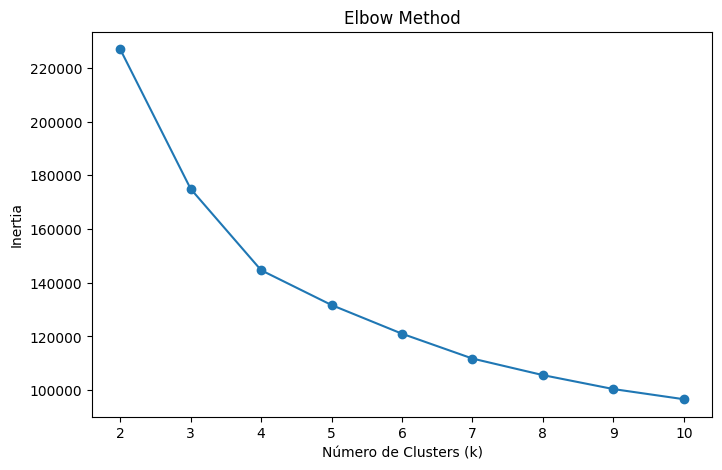

In [3]:
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')

plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

### Método Silhouette

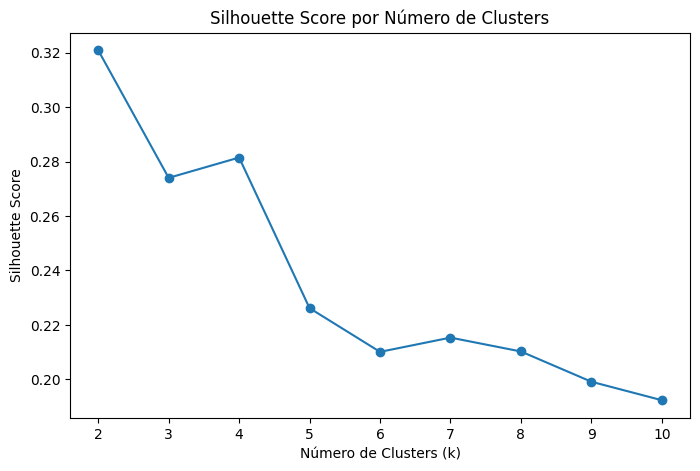

In [4]:
silhouette_scores = []

for k in range(2,11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), silhouette_scores, marker='o')

plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por Número de Clusters")

plt.show()

#### Insight
O método do Elbow mostra uma redução acentuada da inércia até aproximadamente k = 4, ponto a partir do qual os ganhos adicionais na redução da variabilidade interna tornam-se marginais. De forma complementar, o Silhouette Score apresenta valores relativamente elevados nessa mesma região, indicando separação moderada entre os grupos e boa coesão interna, padrão comum em sistemas ambientais onde os gradientes variam de forma contínua no espaço.
A convergência dessas duas métricas sugere que k = 4 representa um equilíbrio adequado entre simplicidade do modelo e qualidade da segmentação, sendo portanto adotado como o número de clusters para a análise.

## Escolha do Algoritmo de Clusterização
Para identificar padrões naturais de agrupamento entre as amostras de solo, foi selecionado o algoritmo K-Means, uma das técnicas mais utilizadas em problemas de clusterização. O método particiona os dados em k grupos com base na similaridade entre as observações, minimizando a variabilidade dentro de cada cluster e maximizando a separação entre os grupos.

A escolha desse algoritmo é adequada para o presente dataset, pois as variáveis utilizadas são numéricas e foram previamente padronizadas, permitindo a aplicação de métricas de distância de forma consistente. Além disso, o K-Means apresenta boa eficiência computacional mesmo em conjuntos de dados relativamente grandes, tornando-se uma opção robusta para exploração inicial da estrutura dos dados.

A aplicação do algoritmo tem como objetivo identificar possíveis grupos de solos com características químicas semelhantes, permitindo investigar padrões de similaridade entre diferentes regiões e apoiar interpretações relacionadas à variabilidade dos atributos do solo.

## Aplicação da clusterização K-Means

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_sample["cluster"] = clusters

## Interpretação dos clusters

### Perfil das variáveis por cluster (Boxplot)
##### Mostra
- distribuição das propriedades do solo
- diferenças entre clusters
- variabilidade interna

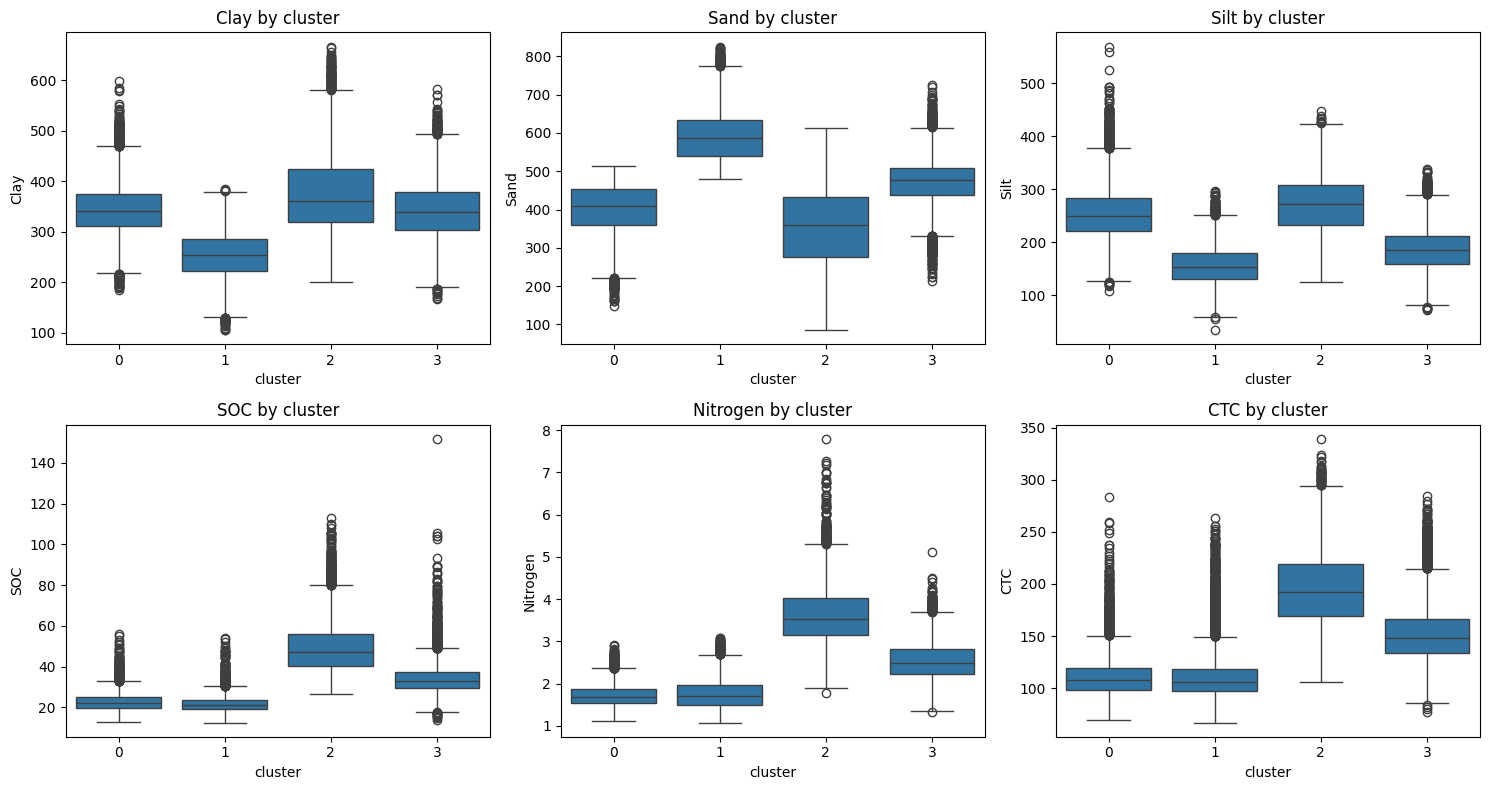

In [6]:
variables = ["Clay", "Sand", "Silt", "SOC", "Nitrogen", "CTC"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, var in enumerate(variables):
    
    row = i // 3
    col = i % 3
    
    sns.boxplot(
        data=df_sample,
        x="cluster",
        y=var,
        ax=axes[row, col]
    )
    
    axes[row, col].set_title(f"{var} by cluster")

plt.tight_layout()
plt.show()

#### Conclusão
A análise dos perfis de solo por cluster revela que a segmentação realizada pelo algoritmo de clusterização está fortemente associada às frações texturais do solo (areia, silte e argila), que constituem o principal gradiente de diferenciação entre os grupos.

Os clusters identificados representam quatro regimes pedológicos distintos: solos arenosos de baixa fertilidade, solos argilosos com maior potencial de retenção de nutrientes, e dois grupos intermediários com diferentes combinações texturais e químicas. Esses padrões são consistentes com processos naturais de formação e distribuição de solos em escala regional.

### Importância das variáveis na diferenciação dos clusters
##### Avalia quais propriedades do solo apresentam maior variação entre clusters.

<Axes: >

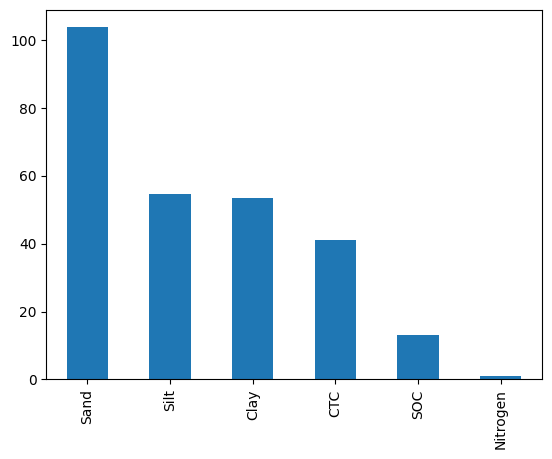

In [7]:
cluster_profile = df_sample.groupby("cluster")[["Clay","Sand","Silt", "SOC","Nitrogen","CTC"]].mean()
importance = cluster_profile.std().sort_values(ascending=False)
importance.plot.bar()

#### Conclusão
O gráfico de importância das variáveis indica quais atributos do solo apresentam maior variabilidade entre os clusters identificados, contribuindo de forma mais significativa para a segmentação dos perfis edáficos.

Observa-se que as frações texturais do solo — especialmente Sand, seguidas por Silt e Clay — são as variáveis que mais diferenciam os clusters. Esse resultado sugere que a textura do solo constitui o principal gradiente ambiental responsável pela formação dos grupos identificados pelo algoritmo de clusterização.

A elevada importância da variável Sand indica que a proporção de areia desempenha papel dominante na separação entre os perfis de solo, distinguindo áreas com solos mais arenosos de regiões com maior conteúdo de argila e silte.

As variáveis químicas, como CTC (Capacidade de Troca Catiônica) e SOC (Carbono Orgânico do Solo), também contribuem para a diferenciação dos clusters, porém com menor intensidade. Isso sugere que as propriedades químicas acompanham parcialmente os gradientes texturais, refletindo processos pedológicos associados à retenção de nutrientes e matéria orgânica.

Por outro lado, a variável Nitrogen apresenta baixa contribuição para a formação dos clusters, indicando que sua variação entre os grupos é relativamente pequena em comparação com os demais atributos analisados.

De forma geral, os resultados indicam que a clusterização dos solos é dominada por gradientes texturais, enquanto as propriedades químicas desempenham papel complementar na caracterização dos perfis edáficos identificados.

### Perfil médio dos clusters (Radar Plot)
##### Mostra a assinatura média de cada cluster, permitindo identificar padrões como:
- solos mais arenosos
- solos mais argilosos
- solos com maior teor de matéria orgânica

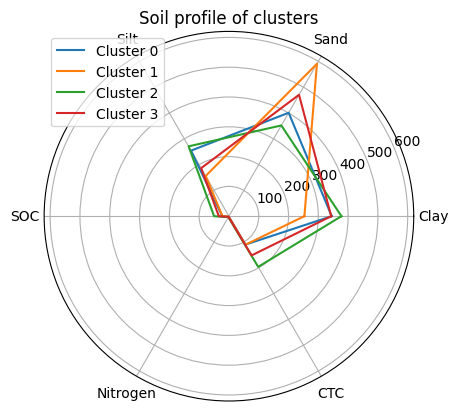

In [8]:
labels = cluster_profile.columns
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

fig = plt.figure()
ax = fig.add_subplot(111, polar=True)

for i in cluster_profile.index:
    values = cluster_profile.loc[i].values
    values = np.concatenate((values,[values[0]]))
    angles_plot = np.concatenate((angles,[angles[0]]))
    
    ax.plot(angles_plot, values, label=f"Cluster {i}")

ax.set_xticks(angles)
ax.set_xticklabels(labels)

plt.legend()
plt.title("Soil profile of clusters")
plt.show()

#### Conclusão
O radar plot evidencia que os clusters identificados apresentam perfis pedológicos distintos, principalmente em função das frações texturais do solo. Observa-se um gradiente que vai de solos mais arenosos e pobres em matéria orgânica até solos mais argilosos com maior teor de carbono orgânico, nitrogênio e capacidade de troca catiônica.

Esse padrão sugere que a textura do solo constitui o principal fator de diferenciação entre os grupos, influenciando diretamente as propriedades químicas e o potencial de fertilidade dos solos analisados.

In [9]:
# Aplicação do pca
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

## Validação estrutural dos clusters
### Visualização dos clusters no espaço de componentes principais (PCA)
##### Avalia se os clusters apresentam separação clara na estrutura multivariada dos dados.

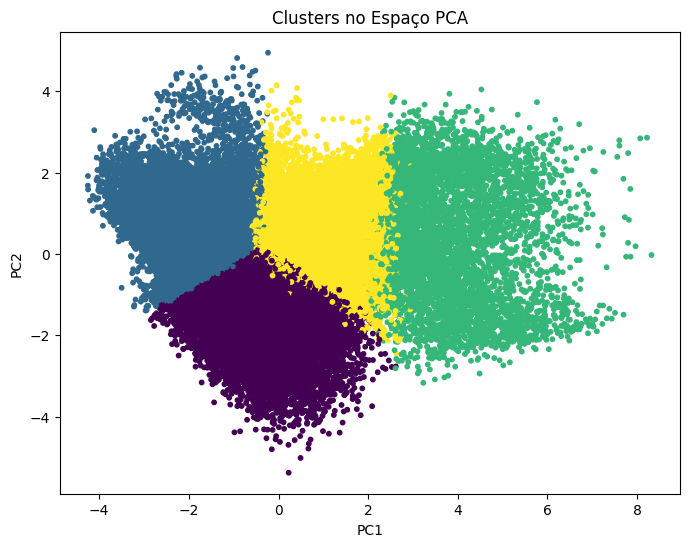

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=clusters, cmap="viridis", s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters no Espaço PCA")
plt.show()

#### Conclusão
A visualização dos clusters no espaço definido pelos dois primeiros componentes principais revela uma separação estrutural entre os grupos identificados pelo algoritmo K-Means, com regiões parcialmente sobrepostas, padrão esperado em sistemas ambientais caracterizados por gradientes contínuos.
Cada cluster ocupa uma região distinta no plano PC1–PC2, indicando que o modelo conseguiu capturar padrões estruturais relevantes presentes no conjunto de dados.
Essa separação sugere a existência de diferentes perfis de solo, definidos por combinações específicas de propriedades químicas e físicas.
A organização dos clusters ao longo dos eixos principais também indica que os gradientes dominantes do dataset, representados pelos componentes principais, desempenham papel fundamental na diferenciação dos grupos.

## Análise espacial dos clusters
### Distribuição percentual dos clusters na área de estudo
##### Mostra a proporção de área ocupada por cada cluster.

In [11]:
scores = []

for seed in range(20):

    kmeans = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

print("Silhouette médio:", sum(scores)/len(scores))
print("Silhouette min:", min(scores))
print("Silhouette max:", max(scores))

Silhouette médio: 0.2815689030547604
Silhouette min: 0.28147286056644033
Silhouette max: 0.2817747775980825


#### Conclusão sobre a validação da estabilidade dos clusters
Como o algoritmo K-Means depende da inicialização aleatória dos centroides, diferentes execuções podem gerar pequenas variações na segmentação dos dados. Para avaliar a robustez da solução obtida, o modelo foi executado múltiplas vezes utilizando diferentes valores de random_state, sendo calculado o Silhouette Score para cada execução.

Os resultados mostram valores praticamente idênticos entre as diferentes execuções (Silhouette médio ≈ 0,2816, com variação inferior a 0,0003), indicando que a estrutura de clusters identificada é estável em relação à inicialização aleatória do algoritmo.

Embora o valor absoluto do Silhouette Score indique uma separação moderada entre os grupos, esse comportamento é consistente com a natureza contínua dos dados ambientais analisados, nos quais gradientes ecológicos e pedológicos tendem a gerar transições graduais entre classes. Assim, os resultados sugerem que a segmentação em quatro clusters representa uma estrutura robusta e consistente presente nos dados.

Os valores de Silhouette obtidos foram consistentes entre as execuções, indicando estabilidade da solução de clusterização.

### Distribuição espacial dos clusters de solo
##### Mapa geográfico mostrando onde cada perfil de solo ocorre.

In [12]:
# pixels por cada cluster
df_sample["cluster"]
cluster_area = df_sample["cluster"].value_counts().sort_index()

cluster_area

cluster
0    14862
1    14991
2     5301
3    14846
Name: count, dtype: int64

In [13]:
# Conversão para porcentagem
cluster_area_pct = (
    df_sample["cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_area_pct

cluster
0    29.724
1    29.982
2    10.602
3    29.692
Name: proportion, dtype: float64

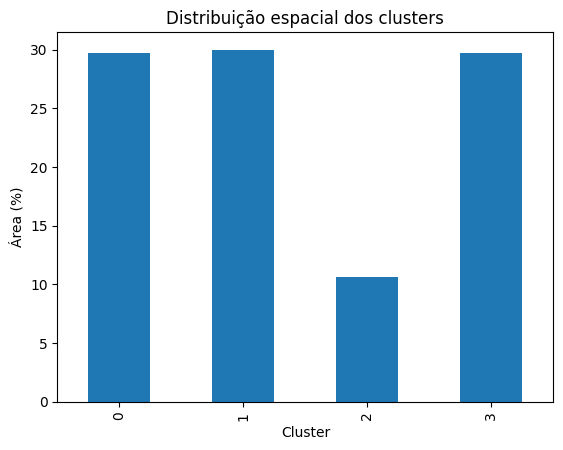

In [14]:
# Visualização
cluster_area_pct.plot.bar()

plt.xlabel("Cluster")
plt.ylabel("Área (%)")
plt.title("Distribuição espacial dos clusters")
plt.show()

#### Conclusão sobre a distribuição espacial dos clusters
Para avaliar a representatividade espacial dos grupos identificados, foi calculada a proporção de pixels pertencentes a cada cluster. Como cada pixel corresponde a uma unidade espacial da área estudada, essa métrica permite estimar a participação relativa de cada tipo de solo na paisagem.

Os resultados mostram que os clusters apresentam diferentes níveis de representatividade espacial, indicando que determinados regimes pedológicos são mais dominantes na região analisada.

Essa análise permite conectar a segmentação obtida pelo algoritmo de clusterização com a estrutura espacial da paisagem pedológica, fornecendo uma interpretação geográfica dos padrões identificados no espaço multivariado.

## Distribuição espacial dos clusters de solo
Esta visualização permite avaliar se os clusters identificados pelo algoritmo K-Means apresentam separação clara na estrutura multivariada dos dados.

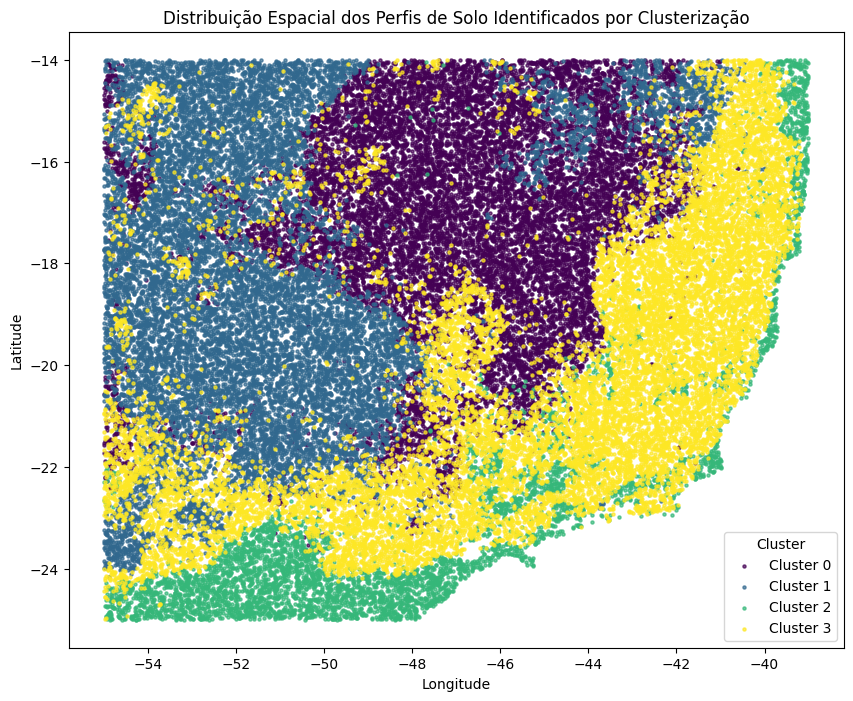

In [15]:
# Paleta fixa para os clusters (viridis)
cluster_colors = {
    0: "#440154",  # roxo
    1: "#31688e",  # azul
    2: "#35b779",  # verde
    3: "#fde725"   # amarelo
}

plt.figure(figsize=(10,8))

for cluster in sorted(df_sample["cluster"].unique()):
    
    subset = df_sample[df_sample["cluster"] == cluster]
    
    plt.scatter(subset["longitude"],
                subset["latitude"],
                s=5,
                color=cluster_colors[cluster],
                label=f"Cluster {cluster}",
                alpha=0.7)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Distribuição Espacial dos Perfis de Solo Identificados por Clusterização")

plt.legend(title="Cluster")

plt.show()

## Conclusão Final
A distribuição espacial dos clusters revela a presença de um gradiente pedológico regional bem definido. Observa-se que os diferentes perfis de solo identificados pelo algoritmo organizam-se em faixas geográficas relativamente contínuas, sugerindo que fatores ambientais regionais exercem influência significativa na estrutura dos dados. Esse padrão indica que a clusterização foi capaz de capturar não apenas similaridades nas propriedades físico-químicas do solo, mas também a organização espacial desses atributos no território analisado.

A análise espacial indica que determinados clusters apresentam maior frequência em regiões específicas do território analisado, sugerindo a presença de gradientes pedológicos regionais.

| Região aproximada  | Cluster predominante observada | Potencial de fertilidade | Textura dominante | Característica pedológica       |
| ------------------ | ------------------------------ | ------------------------ | ----------------- | ------------------------------- |
| Oeste (interior)   | Cluster 1                      | baixo                    | arenoso           | solos mais arenosos             |
| Centro             | Cluster 0                      | médio                    | argiloso          | solos argilosos moderados       |
| Faixa leste        | Cluster 3                      | médio                    | intermediária     | solos intermediários            |
| Litoral sul        | Cluster 2                      | médio-alto               | argiloso          | solos ricos em matéria orgânica |

A estrutura dos clusters sugere a presença de dois gradientes ambientais principais no conjunto de dados: um gradiente químico, relacionado aos teores de carbono orgânico, nitrogênio e capacidade de troca catiônica, e um gradiente textural, associado às proporções de argila e areia. A interação entre esses dois gradientes ambientais favorece a formação de diferentes combinações de características do solo, resultando em quatro regimes pedológicos dominantes identificados pelo algoritmo K-Means. Essa estrutura também se reflete na distribuição espacial dos clusters, indicando que os perfis de solo identificados estão associados a padrões ambientais regionais.

A distribuição espacial dos clusters revela não apenas regiões dominadas por determinados perfis de solo, mas também zonas de transição entre esses grupos. Essas áreas intermediárias apresentam mistura de clusters vizinhos e indicam a presença de gradientes pedológicos naturais. Esse padrão é consistente com o comportamento esperado em sistemas ambientais, nos quais as propriedades do solo variam de forma contínua no espaço, refletindo a influência combinada de fatores como relevo, material de origem e condições climáticas.

É importante destacar que os dados utilizados neste estudo são provenientes do produto SoilGrids, que representa estimativas modeladas de propriedades do solo em escala global. Dessa forma, os padrões identificados devem ser interpretados como aproximações das tendências pedológicas regionais, e não como medições diretas de campo.